<a href="https://colab.research.google.com/github/Fibonancci/algebra-linear-computacional/blob/main/alc_prova2_ufrrj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prova 2 - Álgebra Linear Computacional
---
Realização: Arnoldo Furtado, Lucas Bonan, Paulo Ricardo.

Data: 20/06/2026


# Questão 1

## 1.1 Documentação

Neste exercício, desenvolveremos os algoritmos no programa em Python para automatiza a resolução e a análise de sistemas lineares a partir de dados de um arquivo Excel. O código cobre os principais tópicos de Álgebra Linear Numérica, organizados da seguinte forma:

Começamos com os métodos de resolução de sistemas, passando pelas substituições simples, pelas fatorações LU e QR, e pelos métodos iterativos de Jacobi e Gauss-Seidel. Em seguida, o algoritmo analisa as propriedades matemáticas dessas matrizes e vetores, calculando suas diferentes normas e o número de condição, que mede a estabilidade do sistema. Por fim, exploramos conceitos de geometria analítica computacional, implementando o produto interno e o cálculo de distância tanto entre vetores quanto entre matrizes.

Observação importante: A IA Generativa foi utilizada para auxiliar nas decisões da imprementações do algoritmo a partir dos pseudocódigo.

### Bibliografia
[Forward and Backward substitution Algorithms](https://youtu.be/hnBpWrE7L4k?si=ZUhX6DEeYOfTkRQE)

[Implementação do Método da Fatoração LU](https://youtu.be/7_kottQNcX0?si=wZDWNsI5GDfIQxj3)

[Método Iterativo de Jacobi](https://youtu.be/WqDwBir9JnQ?si=8wdolfzH2mPQlSmX)

[Implementação do Método de Gauss-Seidel](https://https://youtu.be/AP9rIsvxmeg?si=vja-VRThRfC_o57x)

[Normas para vetores e matrizes](https://youtu.be/ZBnOSHR2JNg?si=C9GTg-3CKnzreOcQ)

[Cálculo Numérico: Norma de Vetores e Matrizes](https://youtu.be/XK5-mvUi-_U?si=gP07XSsoiml4M78q)

[Norms - Unicamp](https://www.ime.unicamp.br/~andreani/matrizes/Material/normastreften.pdf)



## 1.2 Implementação das Funções

### A. Decomposições e Sistemas Lineares

In [ ]:
#### Autenticador para o google doc
from google.colab import auth
import gspread
from google.auth import default
import pandas as pd

#Autentica o usuário
auth.authenticate_user()
creds, _= default()
gc=gspread.authorize(creds)

# Bibliotica do python
import numpy as np
import math
# Importação das matrizes e vetores a partir do google doc

### Implementação do método de substituição para trás e para frente
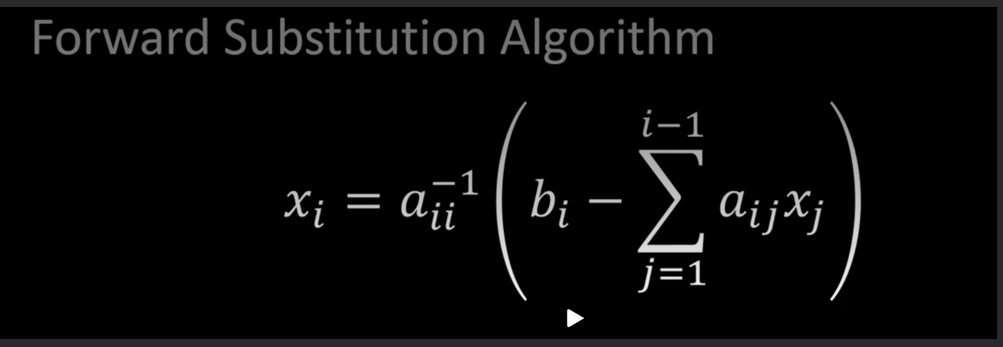





### Fatoração LU

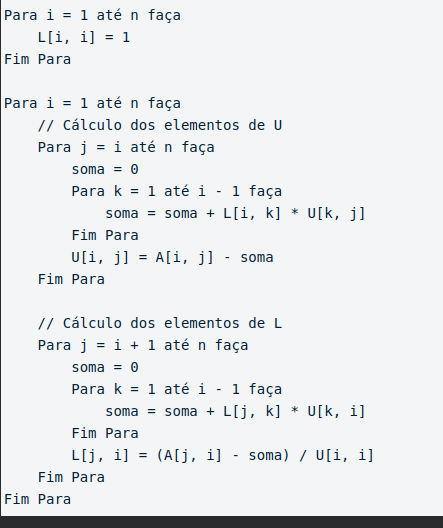

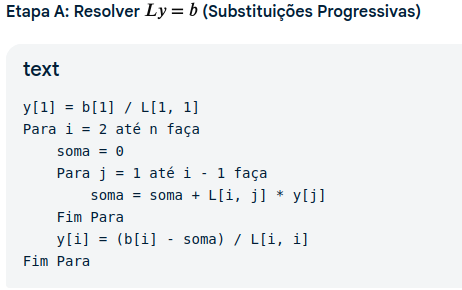

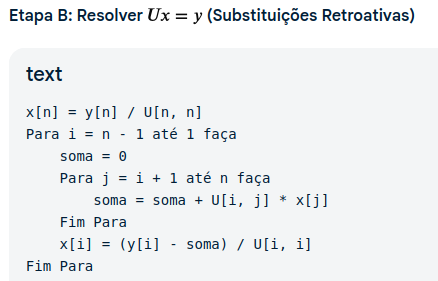


### Método de Jacobi

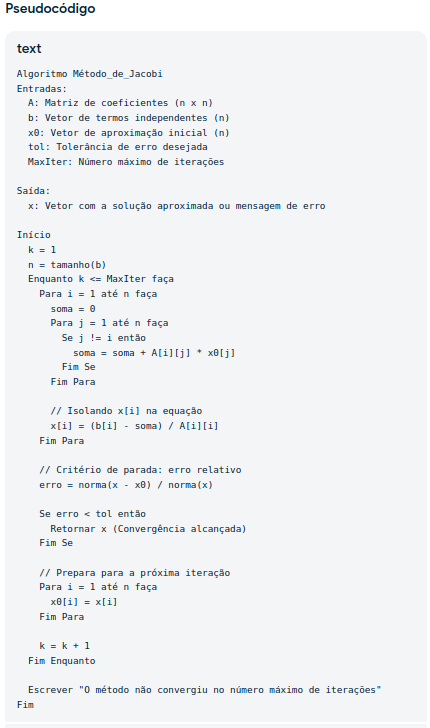

#### Método de Gauss-Seidel

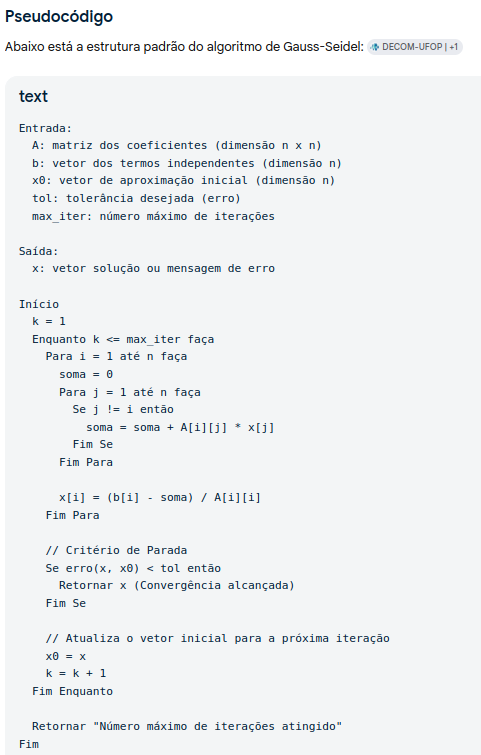

In [ ]:
def SubstituicaoParaFrente(A, b):
  # Revolve o sistema Ax = b, onde A é uma matriz triangular inferior e b é um vetor;
  n = len(b)
  x = np.zeros(n) #criar um vetor de zeros para amazenar as respostas

  for i in range(n):
    #Multiplicados os termos dos coeficientes
    soma = sum(A[i][j] * x[j] for j in range(i))
    x[i] = (b[i] - soma)/A[i][i]

  return x


def SubstituicaoParaTras(A, b):
  # Resolvendo o sistema Ax = b, onde A é uma matriz triangular superior e b é um vetor;
  n = len(b)
  x = np.zeros(n)

  # Percorre de trás para frente: do índice n-1 até 0
  for i in range(n-1, -1, -1):
    # Soma os termos
    soma = sum(A[i][j] * x[j] for j in range(i+1,n))
    # Calcular o valor da varivel
    x[i] = (b[i]-soma)/A[i][i]

  return x


def fatoracao_lu(A):
    # Converte para float
    A = np.array(A, dtype=float) # Essa funcao recebe um inteiro e transforma num float para aumentar a precisão das contas
    n = len(A) #pegar as linhas da matriz

    # Inicializa as matrizes L e U com zeros
    L = np.zeros((n, n))
    U = np.zeros((n, n))

    # --- Para i = 1 até n faça: L[i, i] = 1
    for i in range(n):
        L[i][i] = 1.0

    # --- Laço principal ---
    for i in range(n):

        # // Cálculo dos elementos de U (Para j = i até n faça)
        for j in range(i, n):
            soma = 0
            # Para k = 1 até i - 1 faça
            for k in range(i):
                soma = soma + L[i][k] * U[k][j]
            U[i][j] = A[i][j] - soma

        # // Cálculo dos elementos de L (Para j = i + 1 até n faça)
        for j in range(i + 1, n):
            soma = 0
            # Para k = 1 até i - 1 faça
            for k in range(i):
                soma = soma + L[j][k] * U[k][i]
            L[j][i] = (A[j][i] - soma) / U[i][i]

    return L, U

def metodo_jacobi(A, b, x0, tol, max_iter):
    # Converte as entradas para arrays do NumPy com tipo float
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    x0 = np.array(x0, dtype=float)

    n = len(b)
    x = np.zeros(n)
    k = 1

    # Enquanto k <= MaxIter faça
    while k <= max_iter:

        # Para i = 1 até n faça
        for i in range(n):
            soma = 0

            # Para j = 1 até n faça
            for j in range(n):
                # Se j != i então
                if j != i:
                    soma = soma + A[i][j] * x0[j]

            # Isolando x[i] na equação
            x[i] = (b[i] - soma) / A[i][i]

        # Critério de parada: erro relativo usando a norma vetorial
        erro = np.linalg.norm(x - x0) / np.linalg.norm(x)

        # Se erro < tol então
        if erro < tol:
            print(f"Convergência alcançada na iteração {k}!")
            return x

        # Prepara para a próxima iteração (x0 = x)
        for i in range(n):
            x0[i] = x[i]

        k = k + 1

    print("O método não convergiu no número máximo de iterações")
    return None

def metodo_gauss_seidel(A, b, x0, tol, max_iter):
    # Converte as entradas para arrays do NumPy com tipo float
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    x0 = np.array(x0, dtype=float)

    n = len(b)
    # Cria o vetor x copiando os valores iniciais de x0
    x = np.copy(x0)
    k = 1

    # Enquanto k <= max_iter faça
    while k <= max_iter:

        # Para i = 1 até n faça (ajustado para 0 até n-1 no Python)
        for i in range(n):
            soma = 0

            # Para j = 1 até n faça
            for j in range(n):
                # Se j != i então
                if j != i:
                    # Usa o próprio vetor x (que guarda valores novos e antigos misturados)
                    soma = soma + A[i][j] * x[j]

            # Atualiza o x[i] imediatamente
            x[i] = (b[i] - soma) / A[i][i]

        # Critério de Parada: erro relativo usando a norma vetorial
        erro = np.linalg.norm(x - x0) / np.linalg.norm(x)

        # Se erro < tol então
        if erro < tol:
            print(f"Convergência alcançada na iteração {k}!")
            return x

        # Atualiza o vetor inicial para a próxima iteração (x0 = x)
        x0 = np.copy(x)
        k = k + 1

    return "Número máximo de iterações atingido"

### Norma 1, Norma Infinita e Norma de Frobenius

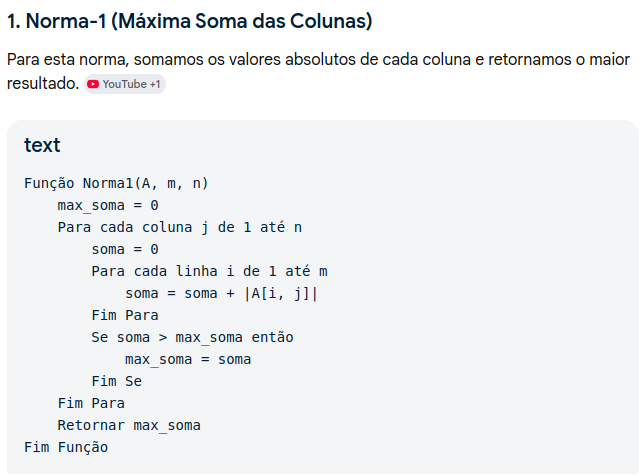

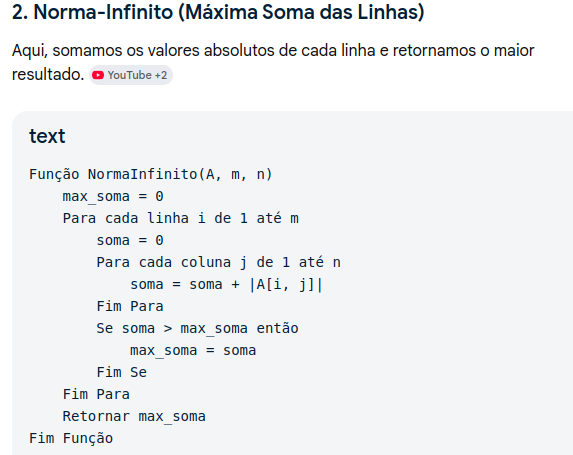

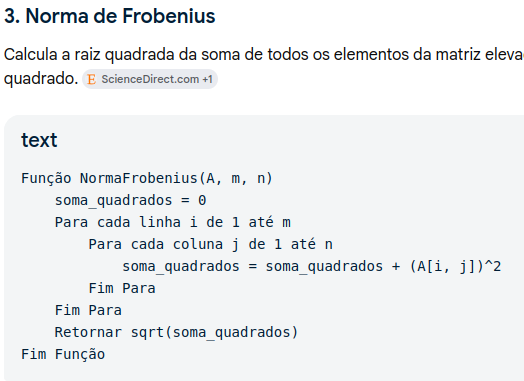

In [ ]:
def norma_1(A):
    # Garante que A seja um array do NumPy
    A = np.array(A, dtype=float)
    m, n = A.shape
    max_soma = 0

    # Para cada coluna j de 1 até n (no Python, de 0 até n-1) #principal diferença entre Norma 1 a Norma-Infinita
    for j in range(n):
        soma = 0

        # Para cada linha i de 1 até m (no Python, de 0 até m-1)
        for i in range(m):
            # abs(A[i][j]) calcula o valor absoluto |A[i, j]|
            soma = soma + abs(A[i][j])

        # Se soma > max_soma então
        if soma > max_soma:
            max_soma = soma

    return max_soma

def norma_infinito(A):
    # Garante que A seja um array do NumPy
    A = np.array(A, dtype=float)
    m, n = A.shape
    max_soma = 0

    # Para cada linha i de 1 até m (no Python, de 0 até m-1) #principal diferença entre Norma 1 a Norma-Infinita
    for i in range(m):
        soma = 0

        # Para cada coluna j de 1 até n (no Python, de 0 até n-1)
        for j in range(n):
            # abs(A[i][j]) calcula o valor absoluto |A[i, j]|
            soma = soma + abs(A[i][j])

        # Se soma > max_soma então
        if soma > max_soma:
            max_soma = soma

    return max_soma

def norma_frobenius(A):
    # Garante que A seja um array do NumPy para manipulação fácil
    A = np.array(A, dtype=float)
    m, n = A.shape
    soma_quadrados = 0

    # Para cada linha i de 1 até m (no Python, de 0 até m-1)
    for i in range(m):
        # Para cada coluna j de 1 até n (no Python, de 0 até n-1)
        for j in range(n):
            soma_quadrados = soma_quadrados + (A[i][j])**2

    # Retornar sqrt(soma_quadrados)
    return math.sqrt(soma_quadrados)

### Norma p (Norma de Holder) e Norma Induzida por uma Matriz Positiva

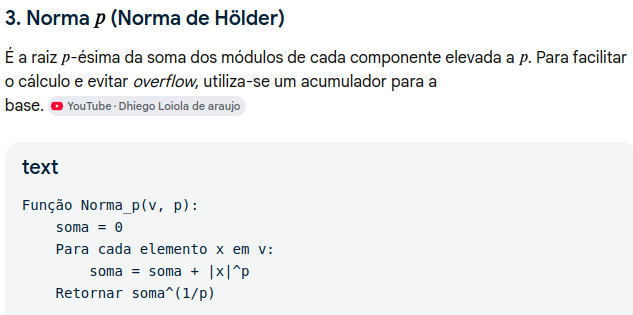

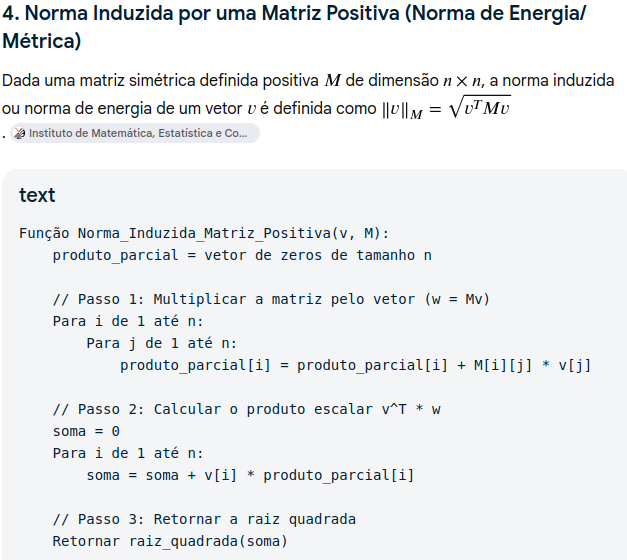

In [ ]:
def norma_induzida_matriz_positiva(b,M):
  # Garante que as entradas sejam arrays do NumPy
  b = np.array(b, dtype=float)
  M = np.array(M, dtype=float)

  n = len(b)
  #produto pacial = vetor de zeros de tamanha n
  produto_parcial = np.zeros(n)

  #passo 1: Multiplicar a matriz pelo vetor(w = Mv)
  for i in range(n):
    for j in range(n):
      produto_parcial[i] = produto_parcial[i] + M[i][j] * b[j]

  #passo 2: Calcular o produto escalar b^T * w
  soma = 0
  for i in range(n):
    soma = soma + b[i] * produto_parcial[i]
  return math.sqrt(soma)

def Norma_p(b,p):
  soma = 0
  for i in range(len(b)):
    soma += abs(b[i])**p
  return soma**(1/p)

### Cálculo do número de condição da matriz

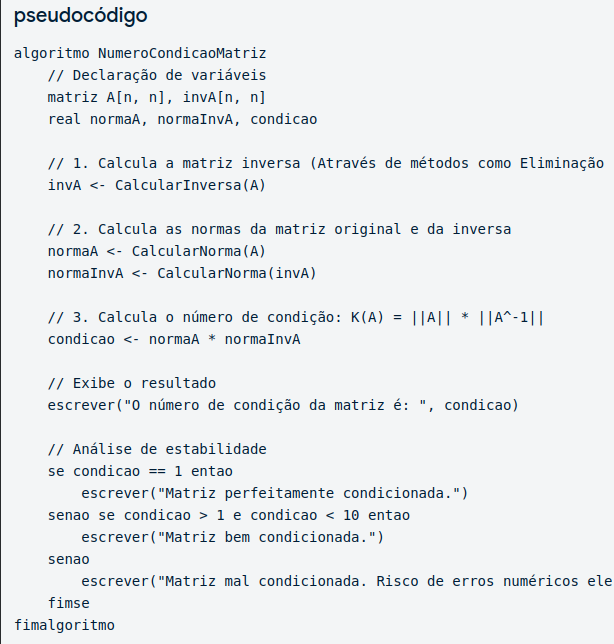

In [ ]:
#Obs:  Por preucação a utilização das funções do python ajudar a diminuir o risco
# de quebra do programa se a matriz não poder ser invertida.
def calcular_numero_condicao(A):
    # 1. Calcula a matriz inversa (Equivalente ao CalcularInversa)
    try:
        invA = np.linalg.inv(A)
    except np.linalg.LinAlgError:
        print("A matriz é singular e não possui inversa.")
        return None

    # 2. Calcula as normas da matriz original e da inversa (Por padrão, usa a Norma 2)
    normaA = np.linalg.norm(A)
    normaInvA = np.linalg.norm(invA)

    # 3. Calcula o número de condição: K(A) = ||A|| * ||A^-1||
    condicao = normaA * normaInvA

    # Exibe o resultado
    print(f"O número de condição da matriz é: {condicao:.4f}")

    # Análise de estabilidade
    if np.isclose(condicao, 1.0):
        print("Matriz perfeitamente condicionada.")
    elif 1.0 < condicao < 10.0:
        print("Matriz bem condicionada.")
    else:
        print("Matriz mal condicionada. Risco de erros numéricos elevados.")

    return condicao

In [ ]:
def estimativa_numero_condicao(A, max_iter=100, tol=1e-6):
    """
    Estimando o número de condição de uma matriz A usando o método das potências inversas,
    """
    n = A.shape[0]

    # 1. Calcular a norma da matriz original (Norma 1)
    norma_A = np.linalg.norm(A, ord=1)

    # 2. Inicializar um vetor aleatório não nulo v
    v = np.random.rand(n, 1)
    v = v / np.linalg.norm(v, ord=1) # Normaliza o vetor inicial

    # Automatizando a Fatoração LU
    # No pseudocódigo genérico "Resolver sistema A * w = v", usando a forma direta
    # para fidelidade matemática ao pseudocódigo.

    for iteracao in range(max_iter):
        # Resolver o sistema A * w = v para encontrar w
        try:
            w = np.linalg.solve(A, v)
        except np.linalg.LinAlgError:
            print("A matriz é singular. Não é possível estimar o número de condição.")
            return None, None

        # Calcular a norma de w
        norma_w = np.linalg.norm(w, ord=1)

        # Próximo vetor iterativo normalizado
        v_novo = w / norma_w

        # Critério de parada baseado na convergência do vetor v
        if np.linalg.norm(v_novo - v, ord=1) < tol:
            v = v_novo
            break

        v = v_novo

    # A norma da inversa é aproximadamente a norma do último vetor w calculado
    norma_inversa_estimada = np.linalg.norm(w, ord=1)

    # Calcular o número de condição estimado
    condicao_estimada = norma_A * norma_inversa_estimada

    return condicao_estimada, norma_A



### B. Análise Matricial e Vetorial

### Produto Interno de Vetores e calculo da distancia entre os vetores A e P

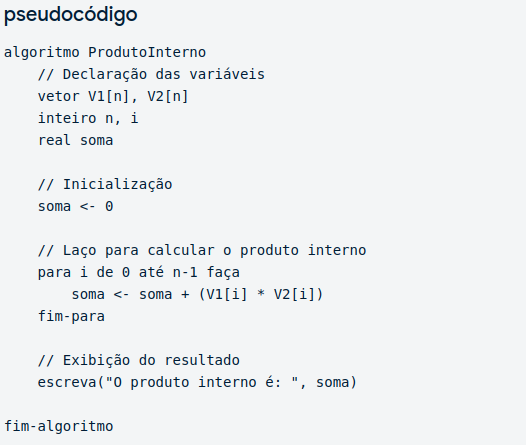

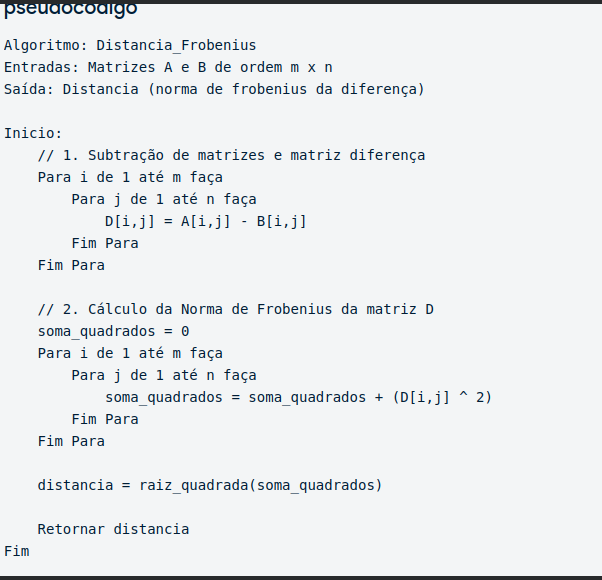

In [ ]:
def calcular_produto_interno(v1, v2):
    # Garante que os vetores sejam unidimensionais (arrays do NumPy)
    v1 = np.array(v1).flatten()
    v2 = np.array(v2).flatten()

    n = len(v1)
    soma = 0.0

    # Laço para calcular o produto interno conforme pseudocódigo
    for i in range(n):
        soma = soma + (v1[i] * v2[i])

    return soma

def calcular_distancia_vetores(v1, v2):
    v1 = np.array(v1).flatten()
    v2 = np.array(v2).flatten()

    # A distância é a norma da diferença: sqrt(<v1-v2, v1-v2>)
    diferenca = v1 - v2
    soma_quadrados = calcular_produto_interno(diferenca, diferenca)

    return np.sqrt(soma_quadrados)


In [ ]:
def calcular_distancia_frobenius(A, B):
    A = np.array(A)
    B = np.array(B)

    m, n = A.shape

    # 1. Subtração de matrizes e matriz diferença D
    # Inicializa a matriz D com zeros
    D = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            D[i, j] = A[i, j] - B[i, j]

    # 2. Cálculo da Norma de Frobenius da matriz D
    soma_quadrados = 0.0
    for i in range(m):
        for j in range(n):
            soma_quadrados = soma_quadrados + (D[i, j] ** 2)

    distancia = np.sqrt(soma_quadrados)
    return distancia


### A decomposição (ou fatoração) QR
### Gram-Schmidt (Ortogonalização)

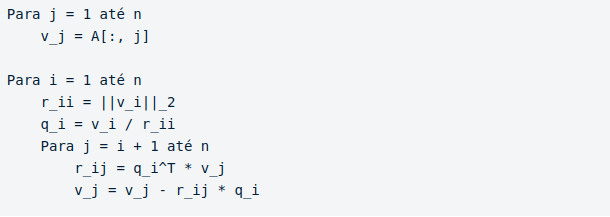

### Reflexões de Householder (Padrão na biblioteca do Matlab)

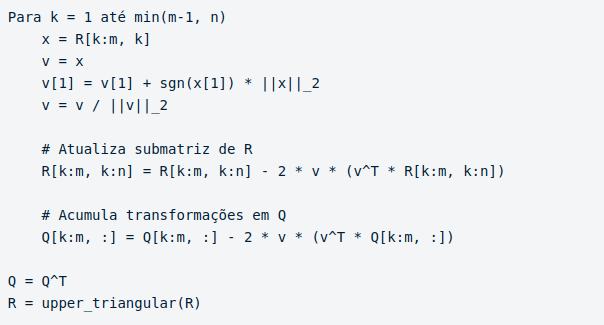


In [ ]:
def fatoracao_qr_gram_schmidt(A_input):
    # Garante que a matriz seja do tipo float para os cálculos
    A = np.array(A_input, dtype=float)
    m, n = A.shape

    # Inicializa as matrizes Q e R com zeros
    Q = np.zeros((m, n))
    R = np.zeros((n, n))

    # Passo 1: Para j = 1 até n -> v_j = A[:, j]
    # Clonar as colunas de A para um array de vetores de trabalho V
    V = np.copy(A)

    # Passo 2: Laço principal de ortogonalização
    for i in range(n):
        # r_ii = ||v_i||_2
        R[i, i] = np.linalg.norm(V[:, i], ord=2)

        # Evitar divisão por zero se a coluna for linearmente dependente
        if R[i, i] == 0:
            raise ValueError("A matriz possui colunas linearmente dependentes.")

        # q_i = v_i / r_ii
        Q[:, i] = V[:, i] / R[i, i]

        # Para j = i + 1 até n
        for j in range(i + 1, n):
            # r_ij = q_i^T * v_j
            R[i, j] = np.dot(Q[:, i], V[:, j])

            # v_j = v_j - r_ij * q_i
            V[:, j] = V[:, j] - R[i, j] * Q[:, i]

    return Q, R



## 1.3 Execução e Testes

In [ ]:
#Matriz de coeficientes A
planilha = gc.open('Matriz') #Código disponiblizado pelo Gemini para importa um matriz a partir de um planilha do google doc.
aba2 = planilha.get_worksheet(3)
dados=aba2.get_all_values()
df=pd.DataFrame(dados)
# --- CORREÇÃO DO ERRO AQUI ---
# 1. Substitui todas as vírgulas por pontos em todos os textos
df = df.replace(',', '.', regex=True)

# 2. Agora sim converte com segurança para float e np.array
A = df.astype(float).to_numpy()

#df.head()
print("Matriz A", A)
print()


planilha = gc.open('Matriz') #Código disponiblizado pelo Gemini para importa um matriz a partir de um planilha do google doc.
aba2 = planilha.get_worksheet(1)
dados=aba2.get_all_values()
df=pd.DataFrame(dados)
# --- CORREÇÃO DO ERRO AQUI ---
# 1. Substitui todas as vírgulas por pontos em todos os textos
df = df.replace(',', '.', regex=True)

# 2. Agora sim converte com segurança para float e np.array
P = df.astype(float).to_numpy()

print("Matriz P", P)
print()

# Vetor b
# --- EXECUÇÃO DO TESTE (Questão g) ---
# Exemplo com vetores
planilha = gc.open('Matriz')
aba = planilha.get_worksheet(2) # <- Verifique se os vetores estão mesmo na aba de índice 1
dados = aba.get_all_values()

# 2. Transforma em DataFrame
df = pd.DataFrame(dados)

# --- CORREÇÃO DO INDEXERROR (Verificação) ---
if df.empty:
    raise ValueError("A aba selecionada está vazia! Verifique o número do get_worksheet.")

# --- CORREÇÃO DO ERRO DA VÍRGULA ---
df = df.replace(',', '.', regex=True)

# 3. Separação dos vetores com segurança
# Se b e c estão lado a lado nas duas primeiras colunas (coluna 0 e coluna 1):
b = df.iloc[:, 0].astype(float).to_numpy()
c = df.iloc[:, 1].astype(float).to_numpy()

print("Vetor b", b)
print()
print("Vetor c", c)


Matriz A [[2. 1. 0.]
 [1. 2. 1.]
 [0. 1. 2.]]

Matriz P [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

Vetor b [1. 2. 3.]

Vetor c [5. 6. 7.]


In [ ]:
# Matriz A
print("Matriz A")
print(A)
#Vetor b
print()
print("Vetor b")
print(b)
print()
print()

print("Substituicao para frente")
print(SubstituicaoParaFrente(A, b))
print()
print("Substituicao para trás")
print(SubstituicaoParaTras(A, b))


Matriz A
[[2. 1. 0.]
 [1. 2. 1.]
 [0. 1. 2.]]

Vetor b
[1. 2. 3.]


Substituicao para frente
[0.5   0.75  1.125]

Substituicao para trás
[0.375 0.25  1.5  ]


In [ ]:
#Matriz A
print("Matriz A")
print(A)
print()
print("Matriz de fatoração LU")
print("L: ", fatoracao_lu(A)[0])
print()
print("U: ", fatoracao_lu(A)[1])

Matriz A
[[2. 1. 0.]
 [1. 2. 1.]
 [0. 1. 2.]]

Matriz de fatoração LU
L:  [[1.         0.         0.        ]
 [0.5        1.         0.        ]
 [0.         0.66666667 1.        ]]

U:  [[2.         1.         0.        ]
 [0.         1.5        1.        ]
 [0.         0.         1.33333333]]


In [ ]:
print("Matriz A")
print(A)
print()
print("Vetor b")
print(b)
print()

# Aproximação inicial x0 (chute inicial zeros)
x0 = [0, 0, 0]

# Parâmetros de controle
tolerancia = 0.001
maximo_iteracoes = 100
print("Método Jacobi")
# Executa o método
solucao = metodo_jacobi(A, b, x0, tolerancia, maximo_iteracoes)
print("Solução aproximada encontrada:", solucao)

Matriz A
[[2. 1. 0.]
 [1. 2. 1.]
 [0. 1. 2.]]

Vetor b
[1. 2. 3.]

Método Jacobi
Convergência alcançada na iteração 22!
Solução aproximada encontrada: [0.49951172 0.         1.49951172]


In [ ]:
print("Matriz A")
print(A)
print()
print("Vetor b")
print(b)
print()
# Aproximação inicial x0 (chute inicial cheio de zeros)
x0 = [0, 0, 0]

# Parâmetros de controle
tolerancia = 0.001
maximo_iteracoes = 100

# Executa o método
print("Metodo Gauss Seidel")
solucao = metodo_gauss_seidel(A, b, x0, tolerancia, maximo_iteracoes)
print("Solução aproximada encontrada:", solucao)

Matriz A
[[2. 1. 0.]
 [1. 2. 1.]
 [0. 1. 2.]]

Vetor b
[1. 2. 3.]

Metodo Gauss Seidel
Convergência alcançada na iteração 11!
Solução aproximada encontrada: [4.99267578e-01 7.32421875e-04 1.49963379e+00]


In [ ]:
# Executa da norma 1
print("Matriz A")
print(A)
print()
#Norma 1
resultado_manual = norma_1(A)
print("Resultado da norma 1:", resultado_manual)

Matriz A
[[2. 1. 0.]
 [1. 2. 1.]
 [0. 1. 2.]]

Resultado da norma 1: 4.0


In [ ]:
# Executar
print("Matriz A")
print(A)
print()
# Norma infinita
resultado_manual2 = norma_infinito(A)
print("Resultado da norma infinita:", resultado_manual2)

Matriz A
[[2. 1. 0.]
 [1. 2. 1.]
 [0. 1. 2.]]

Resultado da norma infinita: 4.0


In [ ]:
# Executar
print("Matriz A")
print(A)
print()
# Norma Frobenius
# Executa
resultado_manual3 = norma_frobenius(A)
print("Resultado norma frobenius:", resultado_manual3)

Matriz A
[[2. 1. 0.]
 [1. 2. 1.]
 [0. 1. 2.]]

Resultado norma frobenius: 4.0


In [ ]:
# Executa a sua função
print("Vetor b")
print(b)
print()
resultado_manual4 = Norma_p(b,2)
print("Resultado norma p:", resultado_manual4)

Vetor b
[1. 2. 3.]

Resultado norma p: 3.7416573867739413


In [ ]:
print("Matriz A")
print(A)
print()
print("Vetor b")
print(b)
print()

print("Norma induzida matriz positiva:", norma_induzida_matriz_positiva(b,A))

Matriz A
[[2. 1. 0.]
 [1. 2. 1.]
 [0. 1. 2.]]

Vetor b
[1. 2. 3.]

Norma induzida matriz positiva: 6.6332495807108


In [ ]:
print("Matriz A")
print(A)
print()

cond = calcular_numero_condicao(A)


Matriz A
[[2. 1. 0.]
 [1. 2. 1.]
 [0. 1. 2.]]

O número de condição da matriz é: 7.2111
Matriz bem condicionada.


In [ ]:
# --- RESOLUÇÃO DA QUESTÃO ---

print("Matriz A do Exercício:")
print(A)
print("-" * 40)

# Executa a estimativa
cond_est, norma_A = estimativa_numero_condicao(A)

if cond_est is not None:
    print(f"Norma 1 da matriz A: {norma_A:.4f}")
    print(f"Número de Condição Estimado (K(A)): {cond_est:.4f}")
    print("-" * 40)

    # Comparação com o valor exato do NumPy para validação do seu exercício
    cond_exato = np.linalg.cond(A, p=1)
    print(f"Número de Condição Exato: {cond_exato:.4f}")

    # Classificação do sistema
    if cond_est > 100:
        print("\nConclusão: A matriz é MAL CONDICIONADA.")
    else:
        print("\nConclusão: A matriz é BEM CONDICIONADA.")

Matriz A do Exercício:
[[2. 1. 0.]
 [1. 2. 1.]
 [0. 1. 2.]]
----------------------------------------
Norma 1 da matriz A: 4.0000
Número de Condição Estimado (K(A)): 6.8284
----------------------------------------
Número de Condição Exato: 8.0000

Conclusão: A matriz é BEM CONDICIONADA.


In [ ]:
print("Vetor b:", b)
print("Vetor c:", c)
print()

prod_interno = calcular_produto_interno(b, c)
dist_vetores = calcular_distancia_vetores(b, c)

print("--- Questão g) ---")
print(f"O produto interno <b, c> é: {prod_interno}")
print(f"A distância entre os vetores b e c é: {dist_vetores:.4f}")

Vetor b: [1. 2. 3.]
Vetor c: [5. 6. 7.]

--- Questão g) ---
O produto interno <b, c> é: 38.0
A distância entre os vetores b e c é: 6.9282


In [ ]:
print("Matriz A")
print(A)
print()
print("Matriz P")
print(P)
print()

dist_matrizes = calcular_distancia_frobenius(A, P)

print()
print(f"A distância de Frobenius entre as matrizes A e P é: {dist_matrizes:.4f}")

Matriz A
[[2. 1. 0.]
 [1. 2. 1.]
 [0. 1. 2.]]

Matriz P
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


A distância de Frobenius entre as matrizes A e P é: 2.2361


# Questão 2

## 1.1 Documentação


**Introdução**

Nesta questão foram utilizadas transformações lineares para a criação de desafios Sudoku.

O jogo Sudoku, além de um puzzle é principalmente uma estrutura matricial, e por esse motivo se torna suscetível a operações de Álgebra Linear sem que haja perda da validade das regras do jogo. Tendo essa motivação foram desenvolvidas funcões de permutação matricial (transposição, permutações de linhas e colunas, mapeamento de valores). Do ponto de vista matemático, as operações utilizadas se equiparam à multiplicação de uma matriz base por uma Matriz de Permutação, garantindo a manutenção da estrutura lógica do Sudoku. Tais operações foram aplicadas sucessivamente e de forma aleatória para garantir a geração de desafios únicos.

**Engenharia de Software**

A arquitetura de sistema foi baseda em boas práticas de engenharia de software e nos fundamentos de programação estruturada. Priozirando um forte divisão de responsabilidades entre funções (modularização) e reutilização de código. Foram adotadas estratégias de integridae dos dados, para preservação da imutabilidade da matriz base. Embora a criação de cópias tenha um custo computacional maior, optou-se por essa abordagem para garantir a persist6encia segura dos dados e facilitar a rastreabilidade do estado do jogo.

**Uso de IA**

A IA Generativa foi utilizada para auxiliar nas decisões arquiteturais. Diante do dilema entre imutabilidade e desempenho, prioziramos a integridade dos dados, uma vez que a implementação de testes mais robustos demandaria um esforço que excederia o cronograma previsto.
Também destacamos o uso da IA para a correção textual deste relatório.

**Testes**

Para o correto funcionamento do algoritmo, a entrada inserida pelo usuário (resposta) deve seguir as orientações: apenas números inteiros, separados por espaço (ex.: 5 4 8 7 6).

Como conclusão, foram realizados testes de execução com ênfase na interação com o usuário, examinando fluxos alternativos e comportamentos inesperados durante a captura de respostas do jogador. Este processo motivou a inclusão de mecanismos de tratamento de dados e exceções, garantindo que o sistema responda de forma amigável à entradas inválidas, contribuindo para a experiência de jogo.

---
**Bibliografia**

WIKIPÉDIA. Sudoku. Disponível em: https://pt.wikipedia.org/wiki/Sudoku. Acesso em: 6 jun. 2026.

SUPERINTERESSANTE. Sudoku: a história e a lógica por trás do puzzle mais popular do mundo. Disponível em: https://super.abril.com.br/cultura/sudoku-a-historia-e-a-logica-por-tras-do-puzzle-mais-popular-do-mundo/. Acesso em: 6 jun. 2026.

Synapse Data Science. Como usar vetores e matrizes em Python | Biblioteca NumPy. YouTube, 2026. Disponível em: https://www.youtube.com/watch?v=r_UDEdxxdvw. Acesso em: 7 jun. 2026.

Hashtag Programação. Introdução ao Pandas no Python - SAIA DO ZERO EM 1 AULA. YouTube, 2026. Disponível em: https://www.youtube.com/watch?v=C0aj3FjN5e0. Acesso em: 7 jun. 2026.

## 1.2 Implementação das Funções

In [ ]:
# -------------- Import --------------
import pandas as pd
import numpy as np
import math
import random as rd

# -------------- Funcoes utilirárias --------------
def pegar_m_linhas(matriz_in):
  m = len(matriz_in) # Obtém o m da matriz recebida (quantidade de linhas)
  return m

# Funcao para obter dois números aleatórios diferentes
def gerar_dois_aleatorios(start, stop):
  n_achei = True # Variável de controle para o looping

  while n_achei: # Gera dois números aleatórios
    num1 = rd.randint(start, stop)
    num2 = rd.randint(start, stop)

    if num2 != num1: # Garante que não sejam iguais
      n_achei = False # Interrompe o looping se encontrou números diferentes

  return num1, num2

# -------------- Criação do tabuleiro default/origem --------------

# Funcao geradora da matriz sudoku original (fixa)
def sudoku_orige():
  n = 3;
  matriz_g = np.zeros((n * n, n * n), dtype=int) # Cria uma matriz nula

  for i in range(9):
    for j in range(9):
      matriz_g[i][j] = (i * n + i // n + j) % (n * n) + 1

  return matriz_g # Retorna a matriz gerada

# -------------- Operações Lineares --------------

def gerar_transposta(matriz_in): # Função geradora da transposta da matriz
  m = pegar_m_linhas(matriz_in);
  matriz_aux = np.zeros((m, m), dtype=int) # Cria uma matriz nula auxiliar

  for i in range(m):
    for j in range(m):
      matriz_aux[j][i] = matriz_in[i][j]

  matriz_in[:] = matriz_aux

def trocar_numeros(matriz_in): # Troca dois números aleatórios dentro da matriz recebida
  m = pegar_m_linhas(matriz_in)
  matriz_aux = matriz_in.copy() # Cria uma cópia da matriz
  num1, num2 = gerar_dois_aleatorios(1, 9) # Obtem dois números aleatórios

  for i in range(m):
    for j in range(m):
      aux_troca = matriz_in[i][j]; # Utiliza variável auxiliar para melhor visualização
      if aux_troca == num1: # Troca os números sorteados
        aux_troca = num2
      elif aux_troca == num2:
        aux_troca = num1

      matriz_aux[i][j] = aux_troca # Insere a troca dentro da matriz

  matriz_in[:] = matriz_aux

# Funcao que troca duas linhas aleatórias do mesmo bloco 3x3 da matriz recebida
def trocar_linhas(matriz_in):
  m = pegar_m_linhas(matriz_in)
  matriz_aux = matriz_in.copy()

  bloco_linha = rd.choice([0, 3, 6])
  m1, m2 = gerar_dois_aleatorios(0, 2)
  linha1 = bloco_linha + m1
  linha2 = bloco_linha + m2

  for c in range(m):
    aux_troca = matriz_aux[linha1][c]
    matriz_aux[linha1][c] = matriz_aux[linha2][c]
    matriz_aux[linha2][c] = aux_troca

  matriz_in[:] = matriz_aux

def trocar_colunas(matriz_in): # Funcao que troca duas colunas aleatórias do mesmo bloco 3x3
  gerar_transposta(matriz_in)
  trocar_linhas(matriz_in)
  gerar_transposta(matriz_in)

# -------------- Criação do Desafio Sudoku --------------

# Funcao que gera o puzzle (gabarito)
def gerar_puzzle_gabarito(matriz_in):
  m = pegar_m_linhas(matriz_in)
  matriz_out = matriz_in.copy() # Criando um cópia para não alterar a original

  # Sorteia quantas rodadas de operações serão feitas
  cont_rodadas = 0
  rodadas_sortidas = rd.randint(4, 10)

  # Realiza as operações de forma aleatória
  while cont_rodadas < rodadas_sortidas:
    num_magic = rd.randint(1, 4)
    if num_magic == 1:
      gerar_transposta(matriz_out)
    elif num_magic == 2:
      trocar_numeros(matriz_out)
    elif num_magic == 3:
      trocar_linhas(matriz_out)
    elif num_magic == 4:
      trocar_colunas(matriz_out)
    cont_rodadas += 1

  return matriz_out # retorna o gabarito embaralhado (puzzle)

# Funcao que recebe o gabarito e insere lacunas criando o desafio final
def gerar_puzzle_desafio(matriz_in, nivel):
  m = pegar_m_linhas(matriz_in)
  matriz_out = matriz_in.copy()
  cont_sortidos = 0

  # Quantidade de lacunas desejadas (nivel)
  lacunas = nivel

  # Garante que a contagem pare com o número definido de elementos nulos
  while cont_sortidos < lacunas:
    linha_sortida = rd.randint(0, m - 1)
    coluna_sortida = rd.randint(0, m - 1)

    if matriz_out[linha_sortida][coluna_sortida] != 0:
      matriz_out[linha_sortida][coluna_sortida] = 0
      cont_sortidos += 1

  return matriz_out # retorna uma matriz desafio

# -------------- Tratamento da Resposta --------------

def gerar_matriz_resp_usuario(puzzle_sudoku, resposta_usuario):
  # Tenta converter o texto recebido em uma lista de inteiros
  try:
        lista_resp_usuario = [int(num) for num in resposta_usuario.split()]
  except ValueError:
        print("\nErro: Entrada inválida! Por favor, digite apenas números separados por espaços.")
        return None

  # Contagem de zeros existentes no desafio (lacunas)
  qtd_lacunas = np.count_nonzero(puzzle_sudoku == 0)

  # Valiação da quantidade de números x lacunas na resposta recebida
  if len(lista_resp_usuario) != qtd_lacunas:
          print("\nErro: Você digitou uma quantidade de números incorreta!")
          return None

  m = pegar_m_linhas(puzzle_sudoku)
  matriz_resp_usuario = puzzle_sudoku.copy()
  num_resp = 0 # Indice que anda pela lista de resposta do usuário

  for i in range(m):
    for j in range(m):
      if matriz_resp_usuario[i][j] == 0: # Busca lacunas (elementos vazios)
        matriz_resp_usuario[i][j] = lista_resp_usuario[num_resp] # Preenche as lacunas
        num_resp += 1

  return matriz_resp_usuario

# -------------- Checagem de Acertos --------------

def conferir_acerto_linhas(matriz_resp_usuario):
  # Funcao que busca numeros repetidos em cada linha da matriz
  m = pegar_m_linhas(matriz_resp_usuario)
  for i in range(m):
    linha_atual = matriz_resp_usuario[i]

    if len(set(linha_atual)) != m:
      return False # A resposta do usuario está incorreta
  return True # A resposta do usuario está certa

def conferir_acerto_colunas(matriz_resp_usuario):
  # Funcao que busca numeros repetidos em cada coluna da matriz
  matriz_aux = matriz_resp_usuario.copy()
  gerar_transposta(matriz_aux)

  return conferir_acerto_linhas(matriz_aux)

def conferir_acertos_blocos(matriz_resp_usuario):
  m = pegar_m_linhas(matriz_resp_usuario)
  matriz_bloco_aux = [[0, 0, 0], [0, 0, 0], [0, 0, 0]]

  for linha_inicial in range(0, m, 3):
    for coluna_inicial in range(0, m, 3):

      for i in range(3):
        for j in range(3):
          matriz_bloco_aux[i][j] = matriz_resp_usuario[linha_inicial + i][coluna_inicial + j]

      lista_bloco_aux = matriz_bloco_aux[0] + matriz_bloco_aux[1] + matriz_bloco_aux[2]

      if len(set(lista_bloco_aux)) != m: # funcão set() remove elementos repetidos (conjunto)
        return False # A resposta do usuario está incorreta

  return True # A resposta do usuario está certa

def conferir_resposta_final(matriz_resp_usuario):
  return conferir_acerto_colunas(matriz_resp_usuario) and conferir_acerto_linhas(matriz_resp_usuario) and conferir_acertos_blocos(matriz_resp_usuario)

# -------------- Impressão do Desafio Sudoku --------------

def imprimir_puzzle(puzzle_sudoku):
    m = pegar_m_linhas(puzzle_sudoku)

    print("\n" + "=" * 22) # Topo do tabuleiro

    for i in range(m):
        if i % 3 == 0 and i != 0:
            print("-" * 22)

        linha_texto = ""
        for j in range(m):
            if j % 3 == 0 and j != 0:
                linha_texto += "| "

            if puzzle_sudoku[i][j] == 0:
                linha_texto += ". "
            else:
                linha_texto += str(puzzle_sudoku[i][j]) + " "

        print(linha_texto)

    print("=" * 22 + "\n") # Rodapé do tabuleiro

## 1.3 Execução e Testes

In [ ]:
# -------------- Execução do programa --------------
# O fluxo consiste em:
# 1) Instanciar a matriz base (gabarito mestre);
# 2) Gerar um gabarito único a partir da base (permutação);
# 3) Criar um desafio com lacunas a partir desse gabarito;
# 4) Exibir o puzzle, capturar a resposta do usuário e validar contra o gabarito.

# Instanciando a matriz base
# Essa matriz servirá como referencia para novos desafios
matriz_base = sudoku_orige()

# Gera o gabarito embaralhado e o desafio com as lacunas
sudoku_gabarito1 = gerar_puzzle_gabarito(matriz_base)
sudoku_desafio1 = gerar_puzzle_desafio(sudoku_gabarito1, 6)

# Descomentar essa linha para ver a resposta (cola)
# imprimir_puzzle(sudoku_gabarito1)

# Exibe o puzzle gerado para o jogador
imprimir_puzzle(sudoku_desafio1)

# Captura a resposta do usuário e converte para o formato de matriz
resposta_usuario = input("Informe a resposta em sequência separada por espaços: ")
resposta_final = gerar_matriz_resp_usuario(sudoku_desafio1, resposta_usuario)

# Valida a solução informada pelo usuário
if resposta_final is not None:
  if conferir_resposta_final(resposta_final):
    print("\nSudoku resolvido com sucesso, parabéns!")
  else:
    print("\nNão foi dessa vez, resposta incorreta.")
else:
  print("\nO processamento foi interrompido devido a um erro na entrada.")


7 2 9 | 1 8 3 | 4 5 6 
1 8 3 | 4 5 6 | 7 2 9 
4 5 6 | 7 2 9 | 1 8 3 
----------------------
8 3 4 | 5 6 7 | 2 9 1 
5 6 7 | 2 9 1 | 8 3 4 
2 9 1 | 8 3 4 | 5 6 7 
----------------------
3 4 5 | 6 7 2 | 9 1 8 
9 1 8 | 3 4 5 | 6 7 2 
6 7 2 | 9 1 8 | 3 4 5 


7 2 9 | 1 8 3 | 4 5 6 
1 8 3 | 4 5 6 | 7 2 . 
4 5 6 | 7 2 9 | . 8 3 
----------------------
8 3 4 | 5 6 7 | 2 9 1 
. 6 7 | 2 9 1 | 8 3 4 
2 9 1 | 8 3 4 | 5 6 7 
----------------------
3 4 5 | 6 7 . | 9 1 8 
9 . 8 | 3 4 5 | 6 7 2 
6 7 2 | 9 1 8 | 3 4 . 

Informe a resposta em sequência separada por espaços: bhg

Erro: Entrada inválida! Por favor, digite apenas números separados por espaços.

O processamento foi interrompido devido a um erro na entrada.


# Questão 3

## 1.1 Documentação


**Introdução**

O algoritmo KNN (K-Nearest Neighbors), é amplamente utilizado no aprendizado supervisionado. Sua simplicidade não compromete sua eficiência em classificações baseadas em vizinhança. Com base nisso, esta questão procura desenvolver uma réplica do algoritmo KNN, com a interpretação do estudo prático de aprenizado de máquina.

**Arquitetura Engenharia de Software**

A arquitetura de sistema foi baseda em boas práticas de engenharia de software e nos fundamentos de programação estruturada. Priozirando um forte divisão de responsabilidades entre funções (modularização) e reutilização de código.

É importante destacar que, embora já existam bibliotecas otimizadas para este fim, a implementação manual foi uma decisão eliberada. A utilização e soluções prontas afeta o processo crítico de aprendizagem, portanto, o sistem desenvolvido é um resultado acadêmico, estruturdo para o aprofundamento teórico, sem foco em implementação para ambiente de produção.

**Uso de IA**

A IA Generativa foi utilizada para a correção textual deste relatório. Um uso fundamental foi na orientação sobre a lógica matemática por trás do KNN e as normas utilizadas, agindo como um facilitador pedagógico. Contudo, o seu uso foi evitado durante o desenvolvimento do código-fonte, uma vez que, o foco era a simplicidade e eficácia do algoritmo sem grandes tratamentos de exceções ou práticas avançadas de desenvolvimento de software.

**Testes**

Como conclusão, para o correto funcionamento do algoritmo, os arquivos de entrada devem estar no formato .xls e seguir a estrutura de uma tabela relacional. É obrigatório que a primeira linha contenha os cabeçalhos (rótulos) das colunas. Caso o arquivo de origem não possua etiquetas de, recomenda-se a inserção manual dos nomes das colunas antes da execução do progrma.

---
**Bibliografia**

Synapse Data Science. Como usar vetores e matrizes em Python | Biblioteca NumPy. YouTube, 2026. Disponível em: https://www.youtube.com/watch?v=r_UDEdxxdvw. Acesso em: 7 jun. 2026.

Hashtag Programação. Introdução ao Pandas no Python - SAIA DO ZERO EM 1 AULA. YouTube, 2026. Disponível em: https://www.youtube.com/watch?v=C0aj3FjN5e0. Acesso em: 14 jun. 2026.

IBM. O que é o algoritmo KNN (K-Nearest Neighbors)? IBM Think, 2026. Disponível em: https://www.ibm.com/br-pt/think/topics/knn. Acesso em: 14 jun. 2026.

KDNUGGETS. Most Popular Distance Metrics in Machine Learning. KDnuggets, 2026. Disponível em: https://www.kdnuggets.com/2020/11/most-popular-distance-metrics-knn.html. Acesso em: 14 jun. 2026.

REAL PYTHON. Train-Test Split: Splitting Data in Python. Real Python, 2026. Disponível em: https://realpython.com/train-test-split-python-data/. Acesso em: 14 jun. 2026.

## 1.2 Implementação das Funções

In [ ]:
# -------------- Import --------------
import pandas as pd
import numpy as np
import math

from operator import itemgetter
# Utilizando biblioteca sugerida pelo Gemini
from sklearn.model_selection import train_test_split

# -------------- Pré-Processamento --------------
def normalizar_dados(vx): # vx = vetores da parte x (informações das variáveis)
  # Criando uma cópia (evita perder o antigo vx)
  vx_df = vx.copy()

  # Percorre todas as colunas do dataframe recebido
  for coluna in vx_df.columns:

    # Trata e remove os possíveis valores NaN
    if vx_df[coluna].isnull().any(): # percorre todas as linhas buscando pelo menos um valor nulo
      mediana = vx_df[coluna].median() # insere a mediana da coluna na cédula localizada com NaN
      vx_df[coluna] = vx_df[coluna].fillna(mediana)

    # Com uso da biblioteca NumPy realizamos os cálculos estatísticos
    media = np.mean(vx_df[coluna])
    desvio_pd = np.std(vx_df[coluna])

    # Finalizando o cálculo da fórmula e incluindo o resultado no novo dataframe
    if desvio_pd != 0:
      vx_df[coluna] = (vx_df[coluna] - media) / desvio_pd
    else:
      vx_df[coluna] = 0

  return vx_df

# Nesta função separamos as partes v_x (variaveis) e v_y (rótulos) em mais 4 partes: treino e teste
# Para evitar que o algoritmo "decore" utilizamos uma porcentagem de 0.3 (70% treino e 30% testes)
def dividir_conjunto_dados(v_x, v_y):
  return train_test_split(v_x, v_y, test_size=0.3, random_state=4)

def preparar_base_dados(dataframe):
  # Ignora a primeira linha do arquivo que geralmente é apenas o nome das colunas
  # Reseta os indices do dataframe após remover a primeira linha (indice 1 passa a ser 0 e assim por diante)
  variaveis_df = dataframe.iloc[1:].reset_index(drop=True)

  # O ":" a seguir indica todas as linhas
  # O "-1" indica sempre o ultimo, que neste caso é a ultima coluna
  v_x = variaveis_df.iloc[:, :-1] # captura o x
  v_y = variaveis_df.iloc[:, -1] # captura o y

  # Normaliza os dados antes da divisão dos grupos de teste e treino
  v_x_normalizado = normalizar_dados(v_x)

  # Cria todos os grupos já pre-processados prontos para o KNN
  x_treino, x_teste, y_treino, y_teste = dividir_conjunto_dados(v_x_normalizado, v_y)

  return x_treino, x_teste, y_treino, y_teste

# -------------- Normas --------------

def calcular_norma_l1(vetor1, vetor2):
  # Garantir por segurança que são arrays NumPy
  v1 = np.array(vetor1)
  v2 = np.array(vetor2)

  # Aplicando a fórmula da norma L1 com uso de funções da NumPy
  resultado = np.sum(np.abs(v1 - v2))

  # Sem uso da bib NumPy
  # for i in range(len(vetor1)):
  #   resultado += abs(vetor1[i]-vetor2[i])

  return resultado

def calcular_norma_l2(vetor1, vetor2):
  soma = 0
  # Garantindo que sejam arrays do NumPy para os cálculos
  v1 = np.array(vetor1)
  v2 = np.array(vetor2)

  for i in range(len(vetor1)): # looping para as iterações do somatório
    # Aplicando o cálculo do radicando da norma l2
    soma += (v1[i] - v2[i]) ** 2

  # Retornando o resultado final (raiz quadrada do radicando)
  return math.sqrt(soma)

def calcular_norma_cos_t(vetor1, vetor2):
  soma1 = 0
  soma2 = 0

  # Garantindo que sejam arrays do NumPy para os cálculos
  v1 = np.array(vetor1)
  v2 = np.array(vetor2)

  # Calcular o numerador da fórmula
  numerador = np.sum(v1 * v2)

  # Calcular usando a função de produto escalar do NumPy
  # Numerador = np.dot(v1, v2)

  # Calcular o denominador da fórmula
  for i in range(len(vetor1)): # looping para as iterações do somatório
    # Aplicando o cálculo do radicando da norma l2
    soma1 += (v1[i]) ** 2
    soma2 += (v2[i]) ** 2

  # Calculando o resultado de cada norma
  norma_v1 = math.sqrt(soma1)
  norma_v2 = math.sqrt(soma2)

  # Calculando o produto das normas do v1 e v2
  denominador = norma_v1 * norma_v2

  if denominador == 0:
    return 0

  similaridade = numerador / denominador
  return 1 - similaridade

# -------------- Do algoritmo KNN --------------
# Funcao que executa de fato o algoritmo após todo o tratamento dos dados
# norma = qual norma utilizar, k = janela de busca dos vizinhos
def executar_knn_proprio(xtreino, xteste, ytreino, yteste, k, norma):
  lista_previsoes = []

  for i in range(len(xteste)):
    lista_distancias = []
    variavel_test = xteste.iloc[i]

    for j in range(len(xtreino)):
      variaveil_treino = xtreino.iloc[j]
      classe_variavel_treino = ytreino.iloc[j]

      # Pegamos a distancia para criar o critério de "vizinhos proximos"
      # Para isso calculamos usando a norma escolhida
      if norma==1:
        distancia = calcular_norma_l1(variavel_test,variaveil_treino)
      elif norma==2:
        distancia = calcular_norma_l2(variavel_test,variaveil_treino)
      elif norma==3:
        distancia = calcular_norma_cos_t(variavel_test,variaveil_treino)
      else:
        return print("Codigo da norma informado é inexistente")

      # Criamos uma tupla <distancia,classe> pra identificarmos a classe dos vizinhos
      lista_distancias.append((distancia, classe_variavel_treino))

    # Ordena a lista de distancia com o critério de menor distancia (vizinhos proximos)
    lista_distancias.sort(key=itemgetter(0))

    # Captura a lista de classes apenas dos k vizinhos próximos
    lista_classes = []
    for w in range(k):
      lista_classes.append(lista_distancias[w][1])

    # Escolhe a classe mais forte (aparece mais vezes)
    # Para isso convertemos em série da biblioteca panda
    # Usamos o mode() funcao estatistica que retorna o que desejamos
    previsao = pd.Series(lista_classes).mode()[0]
    # Adicionar a previsao na lista de previsoes
    lista_previsoes.append(previsao)

  acertos = 0
  for i in range(len(lista_previsoes)):
    if lista_previsoes[i] == yteste.iloc[i]:
      acertos +=1

  # Calcula a parcentagem de acertos
  num_teste = len(yteste)
  acuracia = (acertos / num_teste) * 100

  print(f"Resultado do KNN Próprio:")
  print(f"-> Total de testes: {num_teste}")
  print(f"-> Acertos: {acertos}")
  print(f"-> Acurácia: {acuracia:.2f}%")

  # Pequeno debug
  # for i in range(len(listaPrevisoes)):
  #   print(f"Item {i} -> Previsto: {listaPrevisoes[i]} | Real: {yTeste.iloc[i]}")

Resultado do KNN Próprio:
-> Total de testes: 8
-> Acertos: 8
-> Acurácia: 100.00%
Resultado do KNN Próprio:
-> Total de testes: 8
-> Acertos: 8
-> Acurácia: 100.00%
Resultado do KNN Próprio:
-> Total de testes: 8
-> Acertos: 8
-> Acurácia: 100.00%
Codigo da norma informado é inexistente


## 1.3 Execução e Testes

In [ ]:
# -------------- Carregamento do arquivo --------------
# O arquivo deve vir com o padrão: linha 0 possuir a label (título) das colunas
# A linha 0 será sempre ignorada pelo código (conferir a função "preparar_base_dados")
caminho_arquivo = "usePlanilhaAnimais.xlsx"

# -------------- Tratamento de valores ausentes --------------
# Opção 1: Base de dados pequena
# Linhas nulas afetam o cálculos estatísticos e os resultados do KNN
# Preenchemos campos vazios, garantindo que todos os registros contribuam para o cálculo
base_dados_df = pd.read_excel(caminho_arquivo)

# Opção 2: Base de dados grande
# Como o volume de ddos é alto, apenas excluir as linhas com dropna() não prejudica o KNN
# Sem utilizr a mediana, evitamos o viés artificial, levando em conta apenas os dados reais
# base_dados_df = pd.read_excel(caminho_arquivo).dropna()

# -------------- Pré-processamento dos dados --------------
# Obtenção dos dados de treino e teste já tratados a partir da funcão preparar_base_dados
x_treino, x_teste, y_treino, y_teste = preparar_base_dados(base_dados_df)

# -------------- Pequenos debugs --------------
# print("Colunas em x_treino:", x_treino.columns.tolist())
# print("Colunas em x_teste:", x_teste.columns.tolist())

# linhas_repetidas = x_teste.merge(x_treino, how='inner')
# print(f"Quantidade de linhas repetidas entre Treino e Teste: {len(linhas_repetidas)}")

# -------------- Executando o algoritmo KNN --------------
executar_knn_proprio(x_treino, x_teste, y_treino, y_teste, 3, 1)
executar_knn_proprio(x_treino, x_teste, y_treino, y_teste, 3, 2)
executar_knn_proprio(x_treino, x_teste, y_treino, y_teste, 3, 3)
executar_knn_proprio(x_treino, x_teste, y_treino, y_teste, 3, 5)

# Questão 4

## 1.1 Documentação

## 1.2 Implementação das Funções

### A. Decomposições e Sistemas Lineares

### B. Análise Matricial e Vetorial

## 1.3 Execução e Testes